# PROC KRIGE2Dによる医療圏全体の救急外来待ち時間の空間予測


## エグゼクティブサマリー

ある医療システムのネットワーク運営チームは、大都市医療圏内のすべての稼働施設で救急外来(ED)の平均待ち時間(分)を測定し、新しい緊急ケア拠点のためにサービスが手薄な地域を見つける連続的な待ち時間サーフェスを求めています。このノートブックは**90の地理座標付き施設**からなる合成データセットを生成し、ナゲット付きの**通常クリギング**モデルを当てはめ、50km×50kmの医療圏全体に広がる規則格子上でED待ち時間を補間し、すべての格子ノードと3つの緊急ケア候補地点で点予測とクリギング標準誤差を算出します。

90施設全体で観測された待ち時間の平均は**35.5分**(範囲7.5~58.7)です。クリギングされたサーフェスはこの中心をほぼ正確に再現し(格子ノード平均**35.55分**)、静かな南東部の**16.1**から混雑した北西部の**56.4**まで幅があり、予測待ち時間のホットノードはダウンタウンの急増地帯周辺に集中しています。3つの緊急ケア候補地点のうち、ダウンタウン中心部に最も近い地点が最も高い待ち時間(**52.2 ± 7.3分**)を予測しており、最も説得力のある立地根拠となっています。

## データソース

すべてのデータは合成であり、最初のDATAステップ内でインライン生成されます(`call streaminit(20260531)`)。外部ファイルやネットワークファイルは使用しません。

| データセット | 行数 | 変数 | 型 | 説明 |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | 数値 | 都市圏格子内における施設の東方向座標(km、0~50) |
| `ed_sites` | 90 | `north` | 数値 | 都市圏格子内における施設の北方向座標(km、0~50) |
| `ed_sites` | 90 | `site_id` | 文字 | 施設識別子(例: `FAC037`) |
| `ed_sites` | 90 | `wait_min` | 数値 | 観測された平均ED待ち時間(分)。北西-南東の混雑勾配、ダウンタウンの急増、局所ノイズを組み合わせた空間相関のあるサーフェス |

## PROC KRIGE2Dによる救急外来待ち時間の空間予測

ある地域医療システムは、50km×50kmの大都市医療圏に点在する**救急外来と緊急ケアクリニック**を運営しています。各施設は**平均ED待ち時間**(分)を報告します。待ち時間には空間相関があり、混雑した北西の都心部は高く、周辺の南東部施設は低くなります。ネットワーク計画では、新しい緊急ケア拠点が最も圧力を軽減できる空白地帯を特定するために、不確実性を伴う*連続的な*待ち時間サーフェスを求めています。

**PROC KRIGE2D**は二次元の通常クリギングを実行します。セミバリオグラムモデルを使用して、測定された待ち時間を地点の格子上に補間し、すべてのノードで予測値とクリギング標準誤差の両方を返します。この後、次の手順を行います。

1. 現実的な合成施設データセットを生成する。
2. 観測された待ち時間分布をプロファイリングする。
3. 球面モデルとナゲットでクリギングし、サーフェスを確認する。
4. 3つの緊急ケア候補地点で直接予測する。

## ステップ1 - 合成施設データの生成

医療圏全体に90の施設を一様に散布します。背景にある"真の"待ち時間サーフェスは、なだらかな大規模トレンド(北西から南東への混雑勾配と(15, 38)付近の中心的なダウンタウンの盛り上がり)と、なだらかな地域的な渦を組み合わせたものであり、単なるノイズではなく真に空間的自己相関を持つフィールドになっています。日々の報告のばらつきを模した小さな測定ナゲットも加えます。

In [1]:
データ ed_sites;
   呼出 streaminit(20260531);
   長さ site_id $6;
   繰返 i = 1 から 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* 大規模な混雑トレンド: 北西のダウンタウン中心部で高く、
         南東の郊外端に向かって低減する */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* (15, 38)付近を中心とするダウンタウンの急増 */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* 現実的な自己相関を生む、なだらかな地域的な渦 */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* 局所的な報告ノイズ(測定ナゲット) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      もし wait_min < 3 なら wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      出力;
   終了;
   保持 site_id east north wait_min;
実行;

処理 印刷 データ=ed_sites(obs=10) noobs 見出;
   見出 site_id  = "施設ID"
         east     = "東座標(km)"
         north    = "北座標(km)"
         wait_min = "待ち時間(分)";
   表題 '合成ED施設の最初の10件(km座標、待ち時間は分)';
   変数 site_id east north wait_min;
実行;

                                               合成ED施設の最初の10件(km座標、待ち時間は分)                                               

    施設ID        東座標(km)        北座標(km)            待ち時間(分)
FAC001    42.1064239035  44.8746335392               36.7
FAC002    10.6189061789  14.5101311244               36.2
FAC003    48.9064287162    18.61727984               17.7
FAC004     45.555283186   43.264675772               34.5
FAC005    32.9816533373  24.7120124541               32.5
FAC006    31.1796232687  19.1168441231               31.4
FAC007    34.6664652019  35.2149577448               39.2
FAC008    40.5104234712   2.9588781811               17.1
FAC009     9.9213354522  40.5368804705               54.3
FAC010    24.5041747799  22.5897811072               35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## ステップ2 - 観測された待ち時間のプロファイリング

クリギングの前に、サーフェスが妥当に分布していることを確認します。簡単な`PROC MEANS`の要約により、クリギングされたサーフェスが再現すべき範囲と中心傾向がわかります。90施設の平均は**35.5分**、標準偏差**10.6**であり、最も静かな郊外施設の**7.5**から最も混雑したダウンタウン施設の**58.7**まで幅があります――補間対象として現実的で広い分布です。

In [2]:
処理 平均 データ=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   表題 '施設間の観測ED待ち時間分布';
   変数 wait_min;
   見出 wait_min = "待ち時間(分)";
実行;

                                                     施設間の観測ED待ち時間分布                                                     

                                                  The MEANS Procedure

 Variable  Label                    N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------
 wait_min  待ち時間(分)                 90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 ----------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ3 - 球面モデルによる通常クリギング

`COORDINATES`ステートメントは空間軸を指定し、`PREDICT VAR=`は解析対象変数と探索近傍を指定し、`MODEL`はセミバリオグラムを与えます。ここでは**球面(spherical)**形式(相関が有限の範囲でゼロに近づく場合の標準的な選択)を使用し、以下のパラメータを設定します。

- `SCALE=120` - 部分シル(空間構造で説明される分散)、
- `RANGE=18` - 相関がおよそ18kmで背景レベルに達する、
- `NUGGET=14` - 距離ゼロにおける測定/報告の不連続性。

医療圏全体に広がる規則的な**9×9=81ノード**の格子(`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`)へ補間します――すべてのノードを直接要約・順位付けできる程度に粗く、構造を地図化できる程度に細かい格子です。`OUTEST=`は格子化された予測値と標準誤差を取得し、`OUTNBHD=`は各局所解に何施設が入力されたかを記録します。`PLOTS=`は観測データマップと標準誤差で塗り分けた予測等高線図を要求します。

                                                     施設間の観測ED待ち時間分布                                                     

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


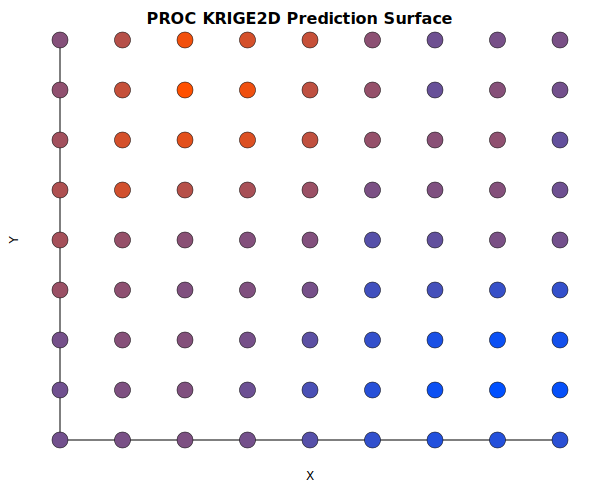

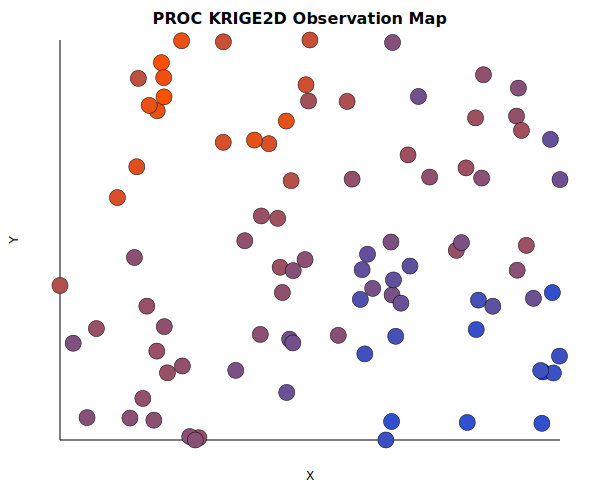

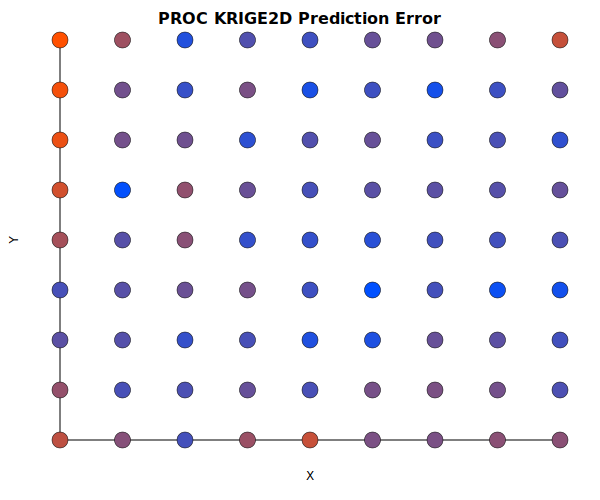

In [3]:
処理 krige2d データ=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   表題 'ED待ち時間の通常クリギング - 球面モデル';
   COORDINATES XC=east YC=north;
   predict 変数=wait_min radius=20 minpoints=10 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 から 50 基準 6 y=0 から 50 基準 6;
実行;

## ステップ4 - クリギングされたサーフェスの確認

`OUTEST=`データセットには、格子ノードごとに予測待ち時間(`estimate`)とそのクリギング標準誤差(`stderr`)を持つ1行が格納されます。サーフェスを要約し、最も予測待ち時間の高いノード――新しい緊急ケア拠点が最も圧力を軽減できる候補地域――を特定します。

クリギングされたサーフェスの平均(**35.55分**)は観測された施設平均(35.5)をほぼ正確に追跡しており、通常クリギングが不偏であることの健全性チェックとなっています。予測値は、施設がまばらな南東部の**16.1**から、混雑した北西部の**56.4**まで幅があります。標準誤差は、施設が密な地域の**5.1**からサンプルの少ない隅の**11.2**まで及びます。最も待ち時間の高い6つのノードはすべて北西象限の(12-18, 36-48)付近に位置し、まさにデータに組み込んだダウンタウンの急増地帯上にあります。

In [4]:
処理 平均 データ=krige_sph n mean MIN MAX maxdec=2;
   表題 'クリギングされたサーフェスの要約(予測待ち時間と標準誤差)';
   変数 estimate stderr;
   見出 estimate = "予測待ち時間(分)"
         stderr   = "標準誤差";
実行;

処理 並替 データ=krige_sph out=hot_nodes;
   基準 DESCENDING estimate;
実行;

処理 印刷 データ=hot_nodes(obs=6) noobs 見出;
   表題 '予測ED待ち時間が最も高い6つの格子ノード';
   変数 x y estimate stderr;
   見出 x        = "X座標(km)"
         y        = "Y座標(km)"
         estimate = "予測待ち時間(分)"
         stderr   = "標準誤差";
実行;

                                             クリギングされたサーフェスの要約(予測待ち時間と標準誤差)                                              

                                                  The MEANS Procedure

 Variable  Label                          N        Mean     Minimum     Maximum
 ------------------------------------------------------------------------------
 ESTIMATE  予測待ち時間(分)                     81       35.55       16.07       56.38
 STDERR    標準誤差                          81        7.38        5.06       11.20
 ------------------------------------------------------------------------------

                                                 予測ED待ち時間が最も高い6つの格子ノード                                                  

    X座標(km)      Y座標(km)                予測待ち時間(分)          標準誤差
         12           42            56.3838526129  6.3860887297
         12           48             54.379464215   5.876759721
         18           42              53.81777091  8.0028060667
         12           36    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## ステップ5 - 特定の候補地点での予測

ネットワーク計画には3つの緊急ケア候補地点があります。各地点を単一ノードの格子(`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`)として与えることで直接クリギングし、計画担当者に正確な座標での予測待ち時間とそのクリギング標準誤差を提供します。

ダウンタウン中心部に近い候補地**(14, 37)**は最も高い予測待ち時間――**52.2 ± 7.3分**――を返し、最も混雑したEDからの需要を吸収することを裏付けています。南東の候補地**(32, 12)**は静かな郊外の一角にあり**22.0 ± 6.2**、北東の候補地**(42, 44)**は中程度の**36.4 ± 5.9**です。予測待ち時間だけを見れば、ダウンタウンの候補地が最も説得力のある立地根拠となります。

In [5]:
処理 krige2d データ=ed_sites outest=cand_dt PLOTS=none;
   表題 '候補地A - ダウンタウン中心部 (14, 37)';
   COORDINATES XC=east YC=north;
   predict 変数=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 から 14 基準 1 y=37 から 37 基準 1;
実行;

処理 krige2d データ=ed_sites outest=cand_se PLOTS=none;
   表題 '候補地B - 郊外南東部 (32, 12)';
   COORDINATES XC=east YC=north;
   predict 変数=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 から 32 基準 1 y=12 から 12 基準 1;
実行;

処理 krige2d データ=ed_sites outest=cand_ne PLOTS=none;
   表題 '候補地C - 北東端 (42, 44)';
   COORDINATES XC=east YC=north;
   predict 変数=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 から 42 基準 1 y=44 から 44 基準 1;
実行;

データ candidates;
   設定 cand_dt cand_se cand_ne;
実行;

処理 印刷 データ=candidates noobs 見出;
   表題 '3つの緊急ケア候補地点における予測ED待ち時間';
   変数 x y estimate stderr;
   見出 x        = "X座標(km)"
         y        = "Y座標(km)"
         estimate = "予測待ち時間(分)"
         stderr   = "標準誤差";
実行;

                                                 予測ED待ち時間が最も高い6つの格子ノード                                                  

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                                                 予測ED待ち時間が最も高い6つの格子ノード                                                  

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


__RESULTS_PLACEHOLDER__